<a href="https://colab.research.google.com/github/pri-2711/qiskit_codes/blob/main/Qiskit_code_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install qiskit
!pip install jupyter
!pip install sympy
!pip install matplotlib
!pip install pylatexenc
!pip install qiskit_aer
!pip install qiskit_ibm_runtime
!pip install qiskit_ibm_provider
!pip install numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 129.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 119.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 116.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.0/913.0 kB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 140.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 16.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=766d8916b3ce93d146c45902973b7e06c67e8ea935ddb1ab70c7481afce760b3
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a1

In [3]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random
import numpy as np

Deutsch-Jozsa Algorithm

In [8]:
#creating Input functions
def dj_query(num_qubits):
    qc=QuantumCircuit(num_qubits+1)
    ''' 2 if condition : decides Constant/ Balanced function
    1st           2nd            result
    0 (no Xgate)  0 (continue)   BALANCED
    0 (no Xgate)  1 (return)     CONSTANT-0
    1 (Xgate)     0 (continue)   Complement BALANCED
    1 (Xgate)     1 (return)     CONSTANT-1'''

    if np.random.randint(0,2):
      qc.x(num_qubits)
    if np.random.randint(0,2):
      #Constant function is returned
      return qc

    ''' Balanced funciton:
    generating possibilities of combinations for result of f(x)'''

    on_states=np.random.choice(
        range(2**num_qubits), # total no.of samples for given no.of qubits
        2**num_qubits//2, # no.of samples to be chosen to change into f(x)=1 -> half other half -> f(x)=0
        replace=False
    )

    # to build a type of balanced function : additional gates in circuit
    def add_cx(qc,bit_string):
      for qubit, bit in enumerate(reversed(bit_string)):
        if bit=="1":
          qc.x(qubit)
        return qc

    for state in on_states:
        qc.barrier()  # Barriers are added to help visualize how the functions are created.
        qc = add_cx(qc, f"{state:0b}")
        qc.mcx(list(range(num_qubits)), num_qubits)
        qc = add_cx(qc, f"{state:0b}")

    qc.barrier()
    return qc


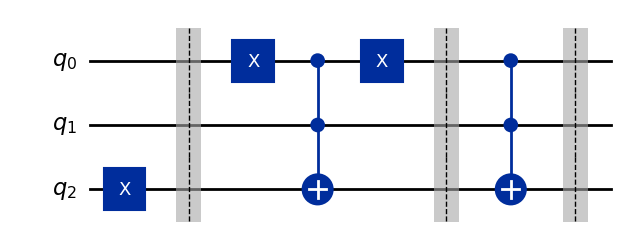

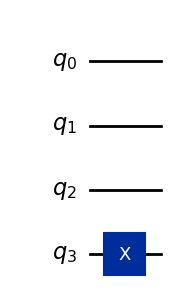

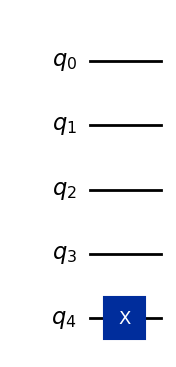

In [9]:
display(dj_query(2).draw(output="mpl"))
display(dj_query(3).draw(output="mpl"))
display(dj_query(4).draw(output="mpl"))